In [10]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [11]:
data = pd.read_csv("IMDB-Dataset.csv")
df = pd.DataFrame(data)

df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [12]:
X = df["review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
vectorizer = CountVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

vectorizer.get_feature_names_out()[:20]


array(['00', '000', '10', '100', '11', '12', '13', '13th', '14', '15',
       '16', '17', '18', '1930', '1930s', '1940', '1950', '1950s', '1960',
       '1960s'], dtype=object)

In [14]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [15]:
y_pred = model.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.8446


In [16]:
test_text = ["Excellent product"]

X_new = vectorizer.transform(test_text)

prediction = model.predict(X_new)
proba = model.predict_proba(X_new)

print("Text:", test_text[0])
print("Predicted Label:", prediction[0])
print("Probability (Negative):", proba[0][0])
print("Probability (Positive):", proba[0][1])


Text: Excellent product
Predicted Label: positive
Probability (Negative): 0.24168484241338148
Probability (Positive): 0.75831515758662


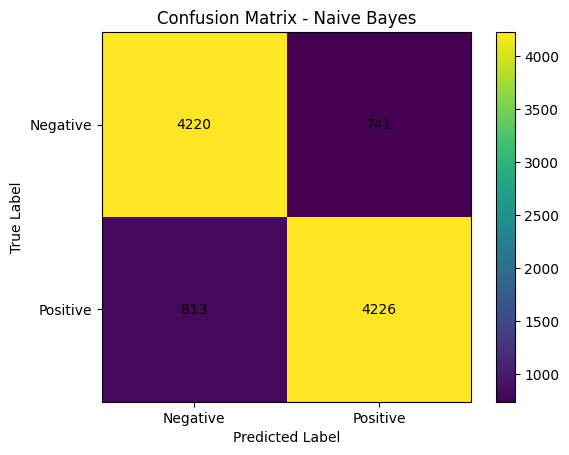

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)
labels = ["Negative", "Positive"]

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(2), labels)
plt.yticks(np.arange(2), labels)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()
